
# Proyecto de análisis de datos (plantilla)
**Alumno/a:** _[pon tu nombre]_  
**Fecha:** __  
**Dataset:** _CSV_



## Checklist (rápido)
- [ ] Cargar el CSV y explicar de dónde sale.
- [ ] Entender las columnas (tipo, unidades, rangos).
- [ ] Limpiar (nulos, duplicados, tipos).
- [ ] Validar (¿los cambios tienen sentido?).
- [ ] Consultas/preguntas al dataset (3–5).
- [ ] Alguna visualización simple y legible.
- [ ] Conclusiones cortas (qué he aprendido).



## 1) Setup


In [ ]:

# Imports básicos
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# Opcional: establecer semilla para reproducibilidad (si haces muestreos/aleatorios)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Opcional: ajustes de pandas para ver más columnas/filas
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)



## 2) Carga de datos
Explica brevemente qué dataset usas y por qué. Si hay licencia/autor, cítalo.


In [45]:

# Ruta al CSV (ajústala)
DATA_PATH = "orders.csv"  # He usado el dataset orders.csv que usamos en el ejercicio UT1_Spark_ETL.ipynb porque tiene varios tipos de datos (numéricos, cadenas, fechas, etc.)

assert os.path.exists(DATA_PATH), f"No se encuentra el CSV en: {DATA_PATH}"

# Leer CSV: si hay separador raro, ajusta sep=";"
df = pd.read_csv(DATA_PATH)  # , sep=";", encoding="utf-8"
df.head()


,order_id,order_date,country,state,customer_age
0,100000,2025-06-13,ES,NEW,33
1,100001,2025-06-04,DE,DELIVERED,46
2,100002,2025-06-29,ES,SHIPPED,42
3,100003,2025-06-25,DE,DELIVERED,36
4,100004,2025-04-13,DE,NEW,46



## 3) Inspección inicial
Idea: forma, columnas, tipos, vistazo a valores raros.


In [46]:

# Tamaño y columnas
df_shape = df.shape
df_cols = df.columns.tolist()
print("Filas, columnas:", df_shape)
print("Columnas:", df_cols)


Filas, columnas: (25000, 5)
Columnas: ['order_id', 'order_date', 'country', 'state', 'customer_age']


In [47]:

# Tipos y nulos
display(df.dtypes)
df.isna().sum().sort_values(ascending=False).head(10)


order_id         int64
order_date      object
country         object
state           object
customer_age     int64
dtype: object

order_id        0
order_date      0
country         0
state           0
customer_age    0
dtype: int64

In [48]:

# Estadísticos básicos (numéricos)
df.describe().T


,count,mean,std,min,25%,50%,75%,max
order_id,25000.0,112499.50000,7217.022701,100000.0,106249.75,112499.5,118749.25,124999.0
customer_age,25000.0,34.63724,9.713948,16.0,28.00,35.0,41.00,72.0


In [49]:

# Estadísticos incluyendo no numéricos (ojo con tablas grandes)
df.describe(include="all").T.head(25)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,25000.0,NaN,NaN,NaN,112499.5,7217.022701,100000.0,106249.75,112499.5,118749.25,124999.0
order_date,25000,251,2025-08-21,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,25000,5,DE,5069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,25000,6,PAID,6269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_age,25000.0,NaN,NaN,NaN,34.63724,9.713948,16.0,28.0,35.0,41.0,72.0



## 4) Limpieza de datos
- Justifica cambios (tipos, nulos, duplicados).
- Guarda versión limpia si procede.


In [50]:

# Ejemplo: conversión de fechas (ajusta nombres)
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce", dayfirst=True)

# Ejemplo: recorte de espacios/strings
for c in ["country", "state"]:
    df[c] = df[c].astype(str).str.strip()

# Duplicados
dups = df.duplicated().sum()
print("Duplicados:", dups)
df = df.drop_duplicates()

fecha_actual = pd.Timestamp.now().strftime("%Y-%m-%d")
# Nulos: decide caso a caso (rellenar/eliminar)
df["customer_age"] = df["customer_age"].fillna(df["customer_age"].median())
df["state"] = df["state"].fillna("NEW")
df["country"] = df["country"].fillna("ES")
df["order_date"] = df["order_date"].fillna(fecha_actual)
df = df.dropna(subset=["order_id"])

# Tipos numéricos/categóricos
df["state"] = df["state"].astype("category")
df["country"] = df["country"].astype("category")

# Revisión de tipos después de conversiones
display(df.dtypes)


Duplicados: 0


C:\Users\jperaltaza\AppData\Local\Temp\ipykernel_4640\3466354050.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce", dayfirst=True)


order_id                 int64
order_date      datetime64[ns]
country               category
state                 category
customer_age             int64
dtype: object

In [56]:

# Validaciones rápidas post-limpieza
print("Shape:", df.shape)
print("Nulos por columna (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))


Shape: (25000, 5)
Nulos por columna (top 10):
order_id        0
order_date      0
country         0
state           0
customer_age    0
dtype: int64



## 5) Consultas al dataset
Plantea 3–5 consultas y respóndelas con código. Ejemplo:
- ¿Cuáles son las 10 categorías con más registros?
- ¿Hay estacionalidad por mes/año?
- ¿Top-N por una métrica?


In [85]:
start = time.time()
# Ejemplo 1: Top 10 categorías (ajusta columna)
print(df["country"].value_counts().head(10))

# Ejemplo 2: Métrica agregada por grupo (ajusta nombres)
print(df.groupby("country")["customer_age"]
    .mean()
    .sort_values(ascending=False)
    .head(10))

# Ejemplo 3: Rango de fechas (si aplica)
df["anio"] = pd.DatetimeIndex(df["order_date"]).year
print(df["anio"].value_counts().sort_index())

# Ejemplo 4: Número de órdenes por mes
df["mes"] = pd.DatetimeIndex(df["order_date"]).month
print(df["mes"].value_counts().sort_index())

# Ejemplo 5: Cantidad de órdenes canceladas
canceladas = df[df["state"].str.lower() == "cancelled"].shape[0]
print("Órdenes canceladas:", canceladas)
end = time.time()
print(f"Tiempo de ejecución: {end - start:.2f} segundos")


country
DE    5069
ES    5031
IT    5028
PT    5028
FR    4844
Name: count, dtype: int64
country
ES    34.706619
FR    34.658134
DE    34.655948
PT    34.597056
IT    34.569014
Name: customer_age, dtype: float64
anio
2025    25000
Name: count, dtype: int64
mes
1    3086
2    2759
3    3091
4    2928
5    3073
6    3089
7    3036
8    3111
9     827
Name: count, dtype: int64
Órdenes canceladas: 2504
Tiempo de ejecución: 0.01 segundos


C:\Users\jperaltaza\AppData\Local\Temp\ipykernel_4640\3533827260.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("country")["customer_age"]



## 6) Visualizaciones sencillas
Evita gráficos recargados. Títulos y ejes claros. Si el dataset es grande, muestrea.


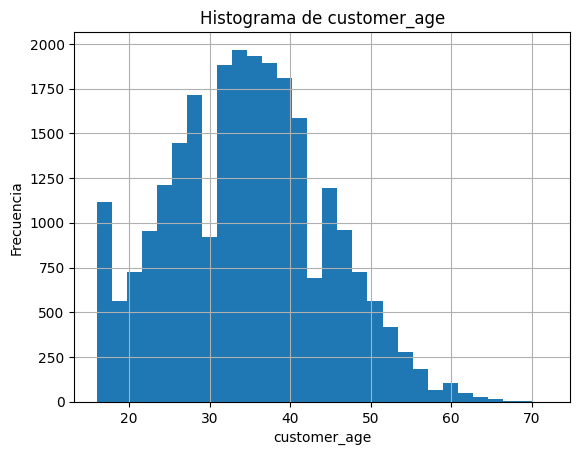

In [69]:

# Ejemplo: histograma variable numérica
col_num = "customer_age"
if col_num and col_num in df.columns:
    plt.figure()
    df[col_num].dropna().hist(bins=30)
    plt.title(f"Histograma de {col_num}")
    plt.xlabel(col_num); plt.ylabel("Frecuencia")
    plt.show()
else:
    print("-> Define 'col_num' con el nombre de una columna numérica")


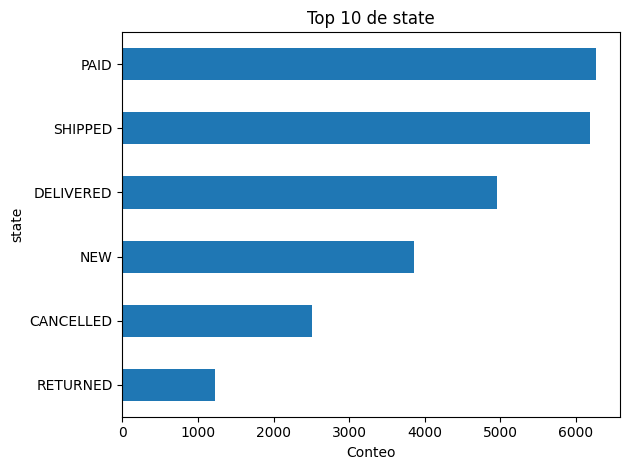

In [72]:

# Ejemplo: barras de top categorías
col_cat = "state"
top_n = 10
if col_cat and col_cat in df.columns:
    plt.figure()
    (df[col_cat].value_counts().head(top_n)
        .sort_values(ascending=True)
        .plot(kind="barh"))
    plt.title(f"Top {top_n} de {col_cat}")
    plt.xlabel("Conteo"); plt.ylabel(col_cat)
    plt.tight_layout()
    plt.show()
else:
    print("-> Define 'col_cat' con el nombre de una columna categórica")



## 7) Conclusiones (breve)
- Resumen de hallazgos (1–4 líneas).
- Posibles siguientes pasos/mejoras.
- Limitaciones del dataset o del trabajo.


### Respuestas
- Me ha parecido importante el tema de poner el tipo de datos de las columnas. Pensé que al leer el CSV ya sabría el tipo de datos de cada columna pero las columnas categóricas y de fecha las trataba como "Object"
- Se podrían hacer más consultas para practicar diferentes métodos.
- Creo que el dataset que he elegido no da tanto juego para hacer consultas, algunas básicas y ya.


## PySpark
Implementa las mismas consultas que has hecho en pandas pero en PySpark y compara los tiempos de ejecución.


In [86]:
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("mini-proyecto").getOrCreate()
sdf = spark.read.csv(DATA_PATH, header=True, inferSchema=True)

start = time.time()
sdf.printSchema()
sdf.show(5, truncate=False)
# Ejemplo 1: Top 10 categorías (ajusta columna)
(sdf.groupBy("country").count().orderBy(F.desc("count")).limit(10)).show()

# Ejemplo 2: Métrica agregada por grupo (promedio de edad por país)
(sdf.groupBy("country")
       .agg(F.avg("customer_age").alias("edad_promedio"))
       .orderBy(F.desc("edad_promedio"))
       .limit(10)
       .show()
)

# Ejemplo 3: Rango de fechas (agregar columna 'anio')
sdf = sdf.withColumn("anio", F.year(F.to_date("order_date")))
(
    sdf.groupBy("anio")
       .count()
       .orderBy("anio")
       .show()
)

# Ejemplo 4: Número de órdenes por mes
sdf = sdf.withColumn("mes", F.month(F.to_date("order_date")))
(
    sdf.groupBy("mes")
       .count()
       .orderBy("mes")
       .show()
)

# Ejemplo 5: Cantidad de órdenes canceladas
canceladas = sdf.filter(F.lower(F.col("state")) == "cancelled").count()
print("Órdenes canceladas:", canceladas)
spark.stop()
end = time.time()
print(f"Tiempo de ejecución con PySpark: {end - start:.2f} segundos")


root
 |-- order_id: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- country: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_age: integer (nullable = true)

+--------+----------+-------+---------+------------+
|order_id|order_date|country|state    |customer_age|
+--------+----------+-------+---------+------------+
|100000  |2025-06-13|ES     |NEW      |33          |
|100001  |2025-06-04|DE     |DELIVERED|46          |
|100002  |2025-06-29|ES     |SHIPPED  |42          |
|100003  |2025-06-25|DE     |DELIVERED|36          |
|100004  |2025-04-13|DE     |NEW      |46          |
+--------+----------+-------+---------+------------+
only showing top 5 rows
+-------+-----+
|country|count|
+-------+-----+
|     DE| 5069|
|     ES| 5031|
|     PT| 5028|
|     IT| 5028|
|     FR| 4844|
+-------+-----+

+-------+------------------+
|country|     edad_promedio|
+-------+------------------+
|     ES| 34.70661896243291|
|     FR| 34.65813377374071|
|


---
### Registro rápido de cambios
- [ ] v0: primera versión (lectura + inspección)
- [ ] v1: limpieza básica
- [ ] v2: consultas y gráficos
- [ ] v3: cierre con conclusiones
